In [1]:
import pandas as pd
import zipfile

# Unzip the file
zip_path = "E:\Data Examples\Hospital+Patient+Records.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/mnt/data/hospital_data")

# Check extracted files
import os
os.listdir("/mnt/data/hospital_data")

# Load main file (assuming it's CSV/Excel inside the ZIP)
encounters = pd.read_csv("/mnt/data/hospital_data/encounters.csv")  
patients = pd.read_csv(r"/mnt/data/hospital_data/patients.csv")
payers = pd.read_csv(r"/mnt/data/hospital_data/payers.csv")
procedures = pd.read_csv(r"/mnt/data/hospital_data/procedures.csv")


<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_7616\1609994220.py:5: SyntaxWarning: invalid escape sequence '\D'
  zip_path = "E:\Data Examples\Hospital+Patient+Records.zip"


In [21]:
# Merge patients with encounters
patients_encounters = pd.merge(
    encounters, patients,
    left_on="PATIENT", right_on="Id",
    suffixes=("_encounter", "_patient")
)

# Merge with procedures
patients_encounters_procedures = pd.merge(
    patients_encounters, procedures,
    left_on="Id_encounter", right_on="ENCOUNTER",
    how="left",
    suffixes=( "", "_procedure")
)

# Merge with payers
full_data = pd.merge(
    patients_encounters_procedures, payers,
    left_on="PAYER", right_on="Id",
    how="left",
    suffixes=("_procedure", "_payer")
)

# Preview final joined data
full_data.head(10)


,Id_encounter,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,...,BASE_COST,REASONCODE_procedure,REASONDESCRIPTION_procedure,Id,NAME,ADDRESS_payer,CITY_payer,STATE_HEADQUARTERED,ZIP_payer,PHONE
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,...,903.0,NaN,NaN,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,...,2477.0,NaN,NaN,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,...,NaN,NaN,NaN,7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,7500 Security Blvd,Baltimore,MD,21244.0,1-800-633-4227
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,...,NaN,NaN,NaN,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,...,NaN,NaN,NaN,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,Anthem,220 Virginia Ave,Indianapolis,IN,46204.0,1-800-331-1476
5,c4923a74-3e40-8b0c-cf73-05b9c0390621,2011-01-03T19:08:16Z,2011-01-03T19:23:16Z,823c6b40-9dbe-e463-310b-ea2b23b23b48,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,wellness,162673000,General examination of patient (procedure),136.80,...,NaN,NaN,NaN,7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,7500 Security Blvd,Baltimore,MD,21244.0,1-800-633-4227
6,c140ed81-040e-8319-e860-f72b4738ed22,2011-01-03T22:39:50Z,2011-01-03T22:54:50Z,9c616fc0-00ea-249f-d073-1f3bb15d41fa,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,Encounter for check up (procedure),85.55,...,NaN,NaN,NaN,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN
7,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,d78e84ec-30aa-3bba-a33a-f29a3a454662,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,ambulatory,185347001,Encounter for problem,85.55,...,11620.0,363406005.0,Malignant tumor of colon,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,Medicaid,7500 Security Blvd,Baltimore,MD,21244.0,1-877-267-2323
8,16bdc066-886f-34e1-38fa-afb85090b637,2011-01-04T15:13:10Z,2011-01-04T15:28:10Z,a80b1160-93f0-db7e-9f23-04ea6fdddfaf,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,...,NaN,NaN,NaN,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN
9,17966936-0878-f4db-128b-a43ae10d0878,2011-01-05T04:02:09Z,2011-01-05T04:17:09Z,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185347001,Encounter for problem,85.55,...,9796.0,162573006.0,Suspected lung cancer (situation),7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,7500 Security Blvd,Baltimore,MD,21244.0,1-800-633-4227


## Patients that have been admitted or readmitted over time

In [14]:
# Count encounters per patient (admissions/readmissions)
admissions = full_data.groupby("PATIENT")["Id_encounter"].count()

# Count encounters over time (by year/month of START date)
full_data["START"] = pd.to_datetime(full_data["START"])
admissions_over_time = full_data.groupby(full_data["START"].dt.to_period("M"))["Id_encounter"].count()

print("Admissions per patient (sample):")
print(admissions.head())

print("\nAdmissions over time:")
print(admissions_over_time.head())


Admissions per patient (sample):
PATIENT
002bc307-2fff-04ba-161b-98cce123e226     54
0034fe01-207f-275f-6b4b-821f7b0af044    189
00abe029-00fa-a666-34f5-258a36978f6d     37
010ff9c1-564b-6e32-09f4-29cb4224bba9      6
01274098-150f-8211-6150-29f2a2da266c      1
Name: Id_encounter, dtype: int64

Admissions over time:
START
2011-01    134
2011-02    175
2011-03    203
2011-04    192
2011-05    259
Freq: M, Name: Id_encounter, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_7616\2539325251.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  admissions_over_time = full_data.groupby(full_data["START"].dt.to_period("M"))["Id_encounter"].count()


## How long are patients staying in the hospital, on average

In [15]:
full_data["STOP"] = pd.to_datetime(full_data["STOP"])
full_data["stay_length_days"] = (full_data["STOP"] - full_data["START"]).dt.days

avg_stay = full_data["stay_length_days"].mean()
print("Average hospital stay length (days):", avg_stay)


Average hospital stay length (days): 0.24958143199501


## Average cost per visit

In [16]:
avg_cost_per_visit = full_data["BASE_ENCOUNTER_COST"].mean()
print("Average cost per visit:", avg_cost_per_visit)


Average cost per visit: 112.42050080430711


In [28]:
full_data["CODE"].value_counts().notnull().sum()

np.int64(45)

## Procedures covered by insurance

In [27]:
# If COVERAGE column exists in payers (some datasets have it)
covered_procedures = full_data[(full_data["NAME"].notnull()) & (full_data["NAME"] != "NO_INSURANCE")]["CODE"].nunique()
total_procedures = full_data["CODE"].nunique()

print(f"Procedures covered by insurance: {covered_procedures}/{total_procedures}")


Procedures covered by insurance: 42/45


## Hospital Data Dashboard

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def hospital_dashboard(full_data):
    # Convert date columns
    full_data["START"] = pd.to_datetime(full_data["START"])
    full_data["STOP"] = pd.to_datetime(full_data["STOP"])
    full_data["stay_length_days"] = (full_data["STOP"] - full_data["START"]).dt.days
    
   
    # 1. Admissions Over Time

    admissions_over_time = full_data.groupby(full_data["START"].dt.to_period("M"))["Id_encounter"].count()
    
    plt.figure(figsize=(10,5))
    admissions_over_time.plot(kind="line", marker="o")
    plt.title("Patient Admissions & Readmissions Over Time")
    plt.xlabel("Month")
    plt.ylabel("Number of Encounters")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

 
    # 2. Distribution of Stay Lengths
  
    plt.figure(figsize=(8,5))
    sns.histplot(full_data["stay_length_days"].dropna(), bins=30, kde=True, color="skyblue")
    plt.title("Distribution of Hospital Stay Lengths")
    plt.xlabel("Stay Length (days)")
    plt.ylabel("Number of Patients")
    plt.show()

    
    # 3. Distribution of Visit Costs
   
    plt.figure(figsize=(8,5))
    sns.histplot(full_data["BASE_ENCOUNTER_COST"].dropna(), bins=30, kde=True, color="orange")
    plt.title("Distribution of Visit Costs")
    plt.xlabel("Cost per Visit")
    plt.ylabel("Number of Encounters")
    plt.show()



C:\Users\HP\AppData\Local\Temp\ipykernel_7616\948279472.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  admissions_over_time = full_data.groupby(full_data["START"].dt.to_period("M"))["Id_encounter"].count()


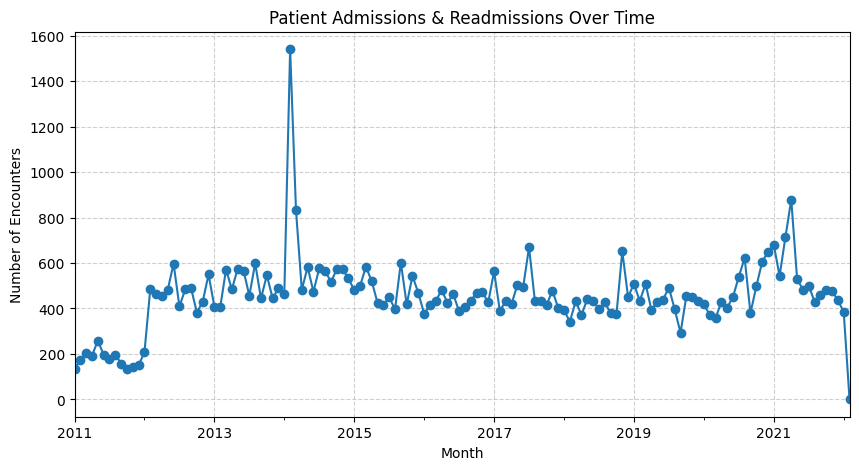

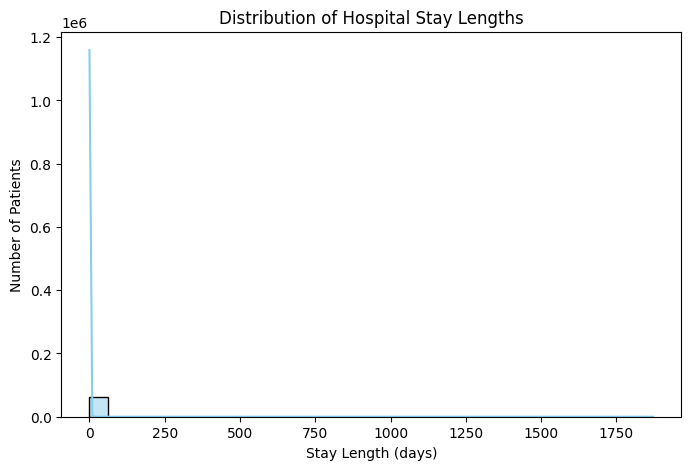

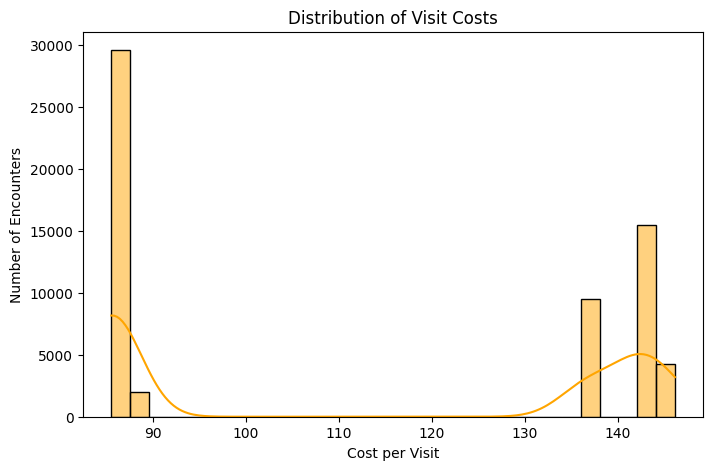

In [51]:
hospital_dashboard(full_data)

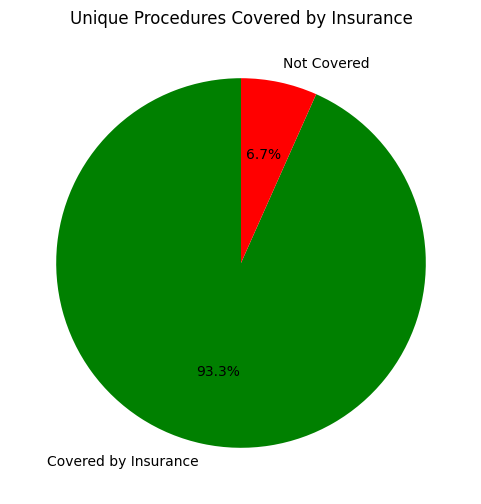

In [55]:
# 4. Procedures Covered by Insurance

covered = full_data[
    (full_data["NAME"].notnull()) & (full_data["NAME"] != "NO_INSURANCE")
]["CODE"].nunique()
total = full_data["CODE"].nunique()
not_covered = total - covered

plt.figure(figsize=(6, 6))
plt.pie(
    [covered, not_covered],
    labels=["Covered by Insurance", "Not Covered"],
    autopct='%1.1f%%',
    colors=["green", "red"],
    startangle=90
)
plt.title("Unique Procedures Covered by Insurance")
plt.show()